In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [121]:
data = pd.read_csv("cyberthreat_data.csv")

In [122]:
data.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),IncidentResolutionLevels
0,Germany,2015,Man-in-the-Middle,IT,54.54,775866,Insider,Weak Passwords,AI-based Detection,69,Slow
1,USA,2015,SQL Injection,Retail,26.98,763017,Insider,Social Engineering,Firewall,24,Moderate
2,Russia,2015,Ransomware,Retail,84.08,71334,Unknown,Unpatched Software,AI-based Detection,26,Moderate
3,Germany,2015,DDoS,Retail,7.84,323011,Nation-state,Social Engineering,Encryption,25,Moderate
4,India,2015,Man-in-the-Middle,Banking,97.28,694308,Nation-state,Weak Passwords,VPN,66,Slow


In [123]:
round(data.groupby("IncidentResolutionLevels")["Financial Loss (in Million $)"].mean(),2)

IncidentResolutionLevels
Fast        50.90
Moderate    50.88
Slow        50.10
Name: Financial Loss (in Million $), dtype: float64

In [124]:
#vulnerability score
#these values need to be normalized, cause they are in different scales 
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
data[["financial_scaled","user_scaled","time_scaled"]]=scaler.fit_transform(
    data[["Financial Loss (in Million $)",
          "Number of Affected Users",
          "Incident Resolution Time (in Hours)"]]
)

data["vulnerabilityScore"]=(
    data["financial_scaled"]*0.4+
    data["user_scaled"]*0.4+
    data["time_scaled"]*0.2
)

data.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),IncidentResolutionLevels,financial_scaled,user_scaled,time_scaled,vulnerabilityScore
0,Germany,2015,Man-in-the-Middle,IT,54.54,775866,Insider,Weak Passwords,AI-based Detection,69,Slow,0.543170,0.776054,0.957746,0.719239
1,USA,2015,SQL Injection,Retail,26.98,763017,Insider,Social Engineering,Firewall,24,Moderate,0.266157,0.763195,0.323944,0.476530
2,Russia,2015,Ransomware,Retail,84.08,71334,Unknown,Unpatched Software,AI-based Detection,26,Moderate,0.840084,0.070966,0.352113,0.434843
3,Germany,2015,DDoS,Retail,7.84,323011,Nation-state,Social Engineering,Encryption,25,Moderate,0.073776,0.322842,0.338028,0.226253
4,India,2015,Man-in-the-Middle,Banking,97.28,694308,Nation-state,Weak Passwords,VPN,66,Slow,0.972761,0.694432,0.915493,0.849976


In [125]:
data.groupby("Country")["vulnerabilityScore"].mean().sort_values(ascending=False)

Country
Brazil       0.524051
Germany      0.517812
Australia    0.508475
USA          0.503093
Russia       0.502445
UK           0.502090
France       0.499438
China        0.495424
Japan        0.495022
India        0.480251
Name: vulnerabilityScore, dtype: float64

In [126]:
# relation between the source and the attack type
source_attack_relation=round(pd.crosstab(data["Attack Source"], data["Attack Type"], normalize="index"),2)
display(source_attack_relation)

Attack Type,DDoS,Malware,Man-in-the-Middle,Phishing,Ransomware,SQL Injection
Attack Source,,,,,,
Hacker Group,0.18,0.17,0.16,0.18,0.17,0.14
Insider,0.20,0.16,0.14,0.17,0.16,0.17
Nation-state,0.17,0.16,0.16,0.18,0.15,0.17
Unknown,0.16,0.16,0.15,0.17,0.17,0.18


In [127]:
#new feature: attackContext
data["attackContext"]=data["Attack Source"]+"_"+data["Attack Type"]

In [128]:
data.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),IncidentResolutionLevels,financial_scaled,user_scaled,time_scaled,vulnerabilityScore,attackContext
0,Germany,2015,Man-in-the-Middle,IT,54.54,775866,Insider,Weak Passwords,AI-based Detection,69,Slow,0.543170,0.776054,0.957746,0.719239,Insider_Man-in-the-Middle
1,USA,2015,SQL Injection,Retail,26.98,763017,Insider,Social Engineering,Firewall,24,Moderate,0.266157,0.763195,0.323944,0.476530,Insider_SQL Injection
2,Russia,2015,Ransomware,Retail,84.08,71334,Unknown,Unpatched Software,AI-based Detection,26,Moderate,0.840084,0.070966,0.352113,0.434843,Unknown_Ransomware
3,Germany,2015,DDoS,Retail,7.84,323011,Nation-state,Social Engineering,Encryption,25,Moderate,0.073776,0.322842,0.338028,0.226253,Nation-state_DDoS
4,India,2015,Man-in-the-Middle,Banking,97.28,694308,Nation-state,Weak Passwords,VPN,66,Slow,0.972761,0.694432,0.915493,0.849976,Nation-state_Man-in-the-Middle


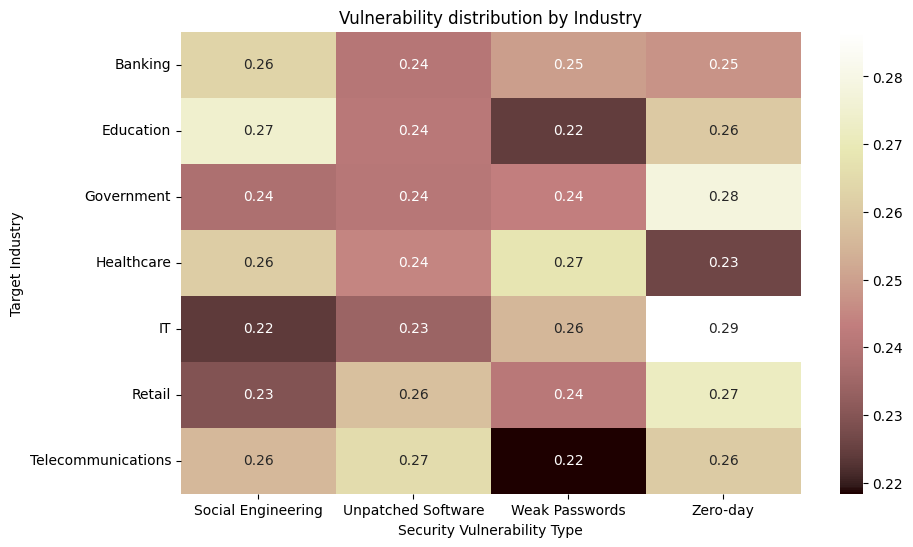

In [129]:
#the target industry often narrates why a certain source uses a specific vulnerability
pattern=data.groupby(["Target Industry", "Attack Source", "Security Vulnerability Type"]).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
industry_vulnerability=pd.crosstab(data["Target Industry"], data["Security Vulnerability Type"], normalize="index")
sns.heatmap(industry_vulnerability, annot=True, cmap="pink")
plt.title("Vulnerability distribution by Industry")
plt.show()

##### Random Forest vs XGBoost

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

In [131]:
#combining columns for the model to learn
data["industryRisk"]=data["Target Industry"]+"_"+data["Security Vulnerability Type"]
data["defense"]=data["Attack Type"]+"_"+data["Defense Mechanism Used"]

In [132]:
#preprocessing 
#encoding categorical columns for the model
lc=LabelEncoder()
categorical=["Country", "Attack Type", "Target Industry", "Attack Source", "Security Vulnerability Type","Defense Mechanism Used", "attackContext", "industryRisk", "defense"]
for col in categorical:
    data[col]=lc.fit_transform(data[col])

#deciding the target and independent variables
#y is IncidentResolutionLevels, rest columns are x
X=data[categorical]
y=lc.fit_transform(data["IncidentResolutionLevels"])
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=43)

##### random forest

In [133]:
rf_model=RandomForestClassifier(n_estimators=100, random_state=43)
rf_model.fit(X_train, y_train)
rf_pred=rf_model.predict(X_test)

##### XGBoost

In [134]:
xgb_model=XGBClassifier(eval_metric="mlogloss")
xgb_model.fit(X_train, y_train)
xgb_pred=xgb_model.predict(X_test)

##### evaluation metrics

In [135]:
print("Random Forest model accuracy")
print(round(accuracy_score(y_test, rf_pred),2))

print("XGBoost Classifier model accuracy")
print(round(accuracy_score(y_test, xgb_pred),2))

Random Forest model accuracy
0.43
XGBoost Classifier model accuracy
0.43


In [136]:
#optimize the model
rf_model1=RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    class_weight="balanced",
    random_state=43
)

rf_model1.fit(X_train,y_train)
predictions=rf_model1.predict(X_test)

print("Optimized model accuracy")
print(round(accuracy_score(y_test,predictions),2))
print(classification_report(y_test,predictions))

Optimized model accuracy
0.43
              precision    recall  f1-score   support

           0       0.13      0.10      0.11        90
           1       0.35      0.29      0.32       204
           2       0.52      0.62      0.57       306

    accuracy                           0.43       600
   macro avg       0.34      0.34      0.33       600
weighted avg       0.41      0.43      0.41       600



In [137]:
data.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours),IncidentResolutionLevels,financial_scaled,user_scaled,time_scaled,vulnerabilityScore,attackContext,industryRisk,defense
0,4,2015,2,4,54.54,775866,1,2,0,69,Slow,0.543170,0.776054,0.957746,0.719239,8,18,10
1,9,2015,5,5,26.98,763017,1,0,3,24,Moderate,0.266157,0.763195,0.323944,0.476530,11,20,28
2,7,2015,4,5,84.08,71334,3,1,0,26,Moderate,0.840084,0.070966,0.352113,0.434843,22,21,20
3,4,2015,0,5,7.84,323011,2,0,2,25,Moderate,0.073776,0.322842,0.338028,0.226253,12,20,2
4,5,2015,2,0,97.28,694308,2,2,4,66,Slow,0.972761,0.694432,0.915493,0.849976,14,2,14


In [138]:
data.to_csv("cyberthreat_final_data.csv",index=False)